# **Нейронная сеть с сигмоидой **


Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2412/2412 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 119.9091 - mae: 8.7318 - val_loss: 64.5066 - val_mae: 6.2812
Epoch 2/50
2412/2412 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 62.7134 - mae: 6.1701 - val_loss: 63.7160 - val_mae: 6.2267
Epoch 3/50
2412/2412 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 61.7581 - mae: 6.1040 - val_loss: 63.5357 - val_mae: 6.2156
Epoch 4/50
2412/2412 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 61.4796 - mae: 6.0794 - val_loss: 63.3465 - val_mae: 6.1905
Epoch 5/50
2412/2412 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 61.5085 - mae: 6.0648 - val_loss: 63.1439 - val_mae: 6.1683
Epoch 6/50
2412/2412 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 61.2422 - mae: 6.0435 - val_loss: 62.9743 - val_mae: 6.1586
Epoch 7/50
2412/2412 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 61.6589 - mae: 6.0738 - val_loss: 62.8672 - val_mae: 6.1470
Epoch 8/50
2412/2412 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 60.9553 - mae: 6.0283 - val_loss: 62.7769 - val_mae: 6.1410
Epoch 9/50
2412/2412 ━━━━━━━━━━━━━

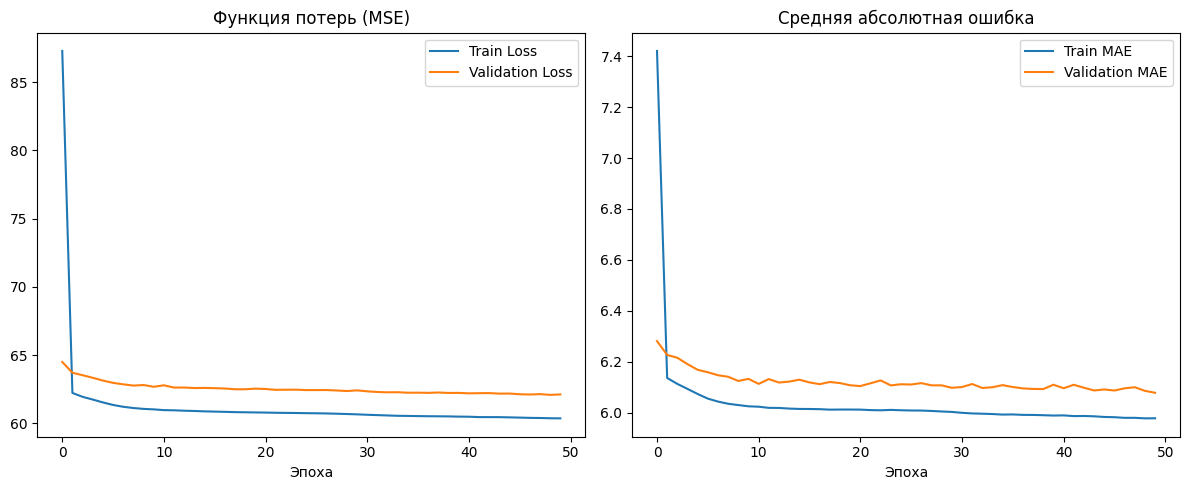


Результаты тестирования:
Средняя абсолютная ошибка (MAE): 6.08°C


In [4]:
# 1. Импорт библиотек
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

# 2. Загрузка данных
df = pd.read_csv('/content/weatherHistory.csv', engine='python', on_bad_lines='skip')

# 3. Предобработка данных
# 3.1. Преобразование времени
df['Formatted Date'] = pd.to_datetime(df['Formatted Date'], utc=True)
df['Hour'] = df['Formatted Date'].dt.hour
df['Day_of_Year'] = df['Formatted Date'].dt.dayofyear

# 3.2. Удаление ненужных столбцов
columns_to_drop = ['Formatted Date', 'Daily Summary', 'Summary']
df = df.drop(columns=columns_to_drop, errors='ignore')

# 3.3. Обработка пропусков
df = df.ffill()

# 4. Выбор признаков и целевой переменной
features = [
    'Humidity',
    'Wind Speed (km/h)',
    'Pressure (millibars)',
    'Hour',
    'Day_of_Year'
]
target = 'Temperature (C)'

X = df[features]
y = df[target]

# 5. Разделение данных
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 6. Стандартизация данных
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 7. Создание простой нейронной сети
model = Sequential([
    Dense(32, activation='sigmoid', input_shape=(X_train_scaled.shape[1],)),
    Dense(16, activation='sigmoid'),
    Dense(1)  # Выходной слой без активации для регрессии
])

# 8. Компиляция модели
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

# 9. Обучение модели
history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=50,
    batch_size=32,
    verbose=1
)

# 10. Визуализация обучения
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Функция потерь (MSE)')
plt.xlabel('Эпоха')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Средняя абсолютная ошибка')
plt.xlabel('Эпоха')
plt.legend()

plt.tight_layout()
plt.show()

# 11. Оценка модели
test_loss, test_mae = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f'\nРезультаты тестирования:')
print(f'Средняя абсолютная ошибка (MAE): {test_mae:.2f}°C')

# Неросеть с relu l2 регуляризацией, батч норм

Epoch 1/50


<ipython-input-5-f5a5434dae09>:25: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1206/1206 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 84.7139 - mae: 7.0183 - root_mean_squared_error: 8.9652 - val_loss: 17.0331 - val_mae: 3.2655 - val_root_mean_squared_error: 4.1136
Epoch 2/50
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 24.7200 - mae: 3.9109 - root_mean_squared_error: 4.9599 - val_loss: 15.7181 - val_mae: 3.1342 - val_root_mean_squared_error: 3.9494
Epoch 3/50
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 21.6495 - mae: 3.6628 - root_mean_squared_error: 4.6396 - val_loss: 15.3679 - val_mae: 3.1076 - val_root_mean_squared_error: 3.9035
Epoch 4/50
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 20.2056 - mae: 3.5410 - root_mean_squared_error: 4.4801 - val_loss: 14.9917 - val_mae: 3.0710 - val_root_mean_squared_error: 3.8533
Epoch 5/50
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 19.2879 - mae: 3.4533 - root_mean_squared_error: 4.3748 - val_loss: 14.3479 - val_mae: 2.9856 - val_root_mean_squared_error: 3.7665
Epoch 6/50
1206/1206 ━━━━━━━━━━━━━━━━━━━━

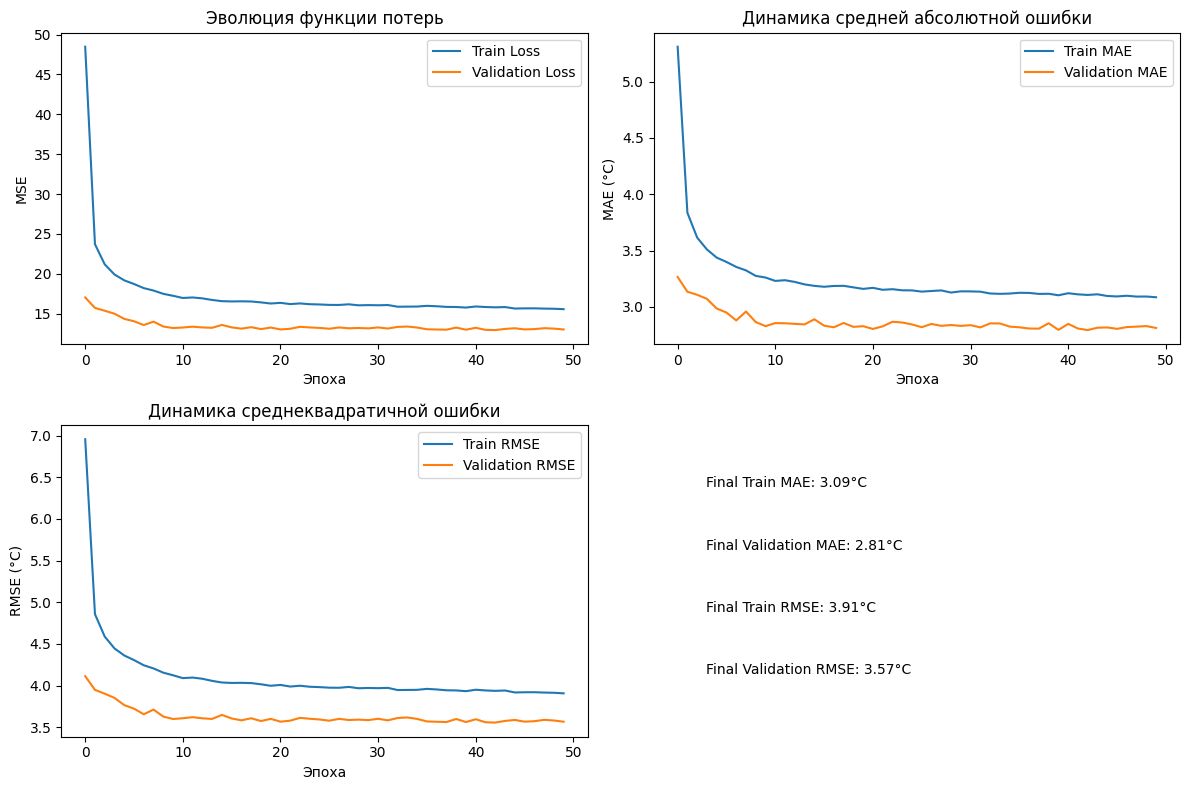


Результаты тестирования:
Средняя абсолютная ошибка (MAE): 2.81°C
Среднеквадратичная ошибка (RMSE): 3.57°C


In [5]:
# 1. Импорт библиотек
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras import regularizers
# 2. Загрузка данных
df = pd.read_csv('/content/weatherHistory.csv')

# 3. Предобработка данных
# 3.1. Преобразование времени
df['Formatted Date'] = pd.to_datetime(df['Formatted Date'], utc=True)
df['Hour'] = df['Formatted Date'].dt.hour
df['Day_of_Year'] = df['Formatted Date'].dt.dayofyear

# 3.2. Удаление ненужных столбцов
columns_to_drop = ['Formatted Date', 'Daily Summary', 'Summary']
df = df.drop(columns=columns_to_drop, errors='ignore')

# 3.3. Обработка пропусков
df = df.fillna(method='ffill')

# 4. Выбор признаков и целевой переменной
features = [
    'Humidity',
    'Wind Speed (km/h)',
    'Pressure (millibars)',
    'Hour',
    'Day_of_Year'
]
target = 'Temperature (C)'

X = df[features]
y = df[target]

# 5. Разделение данных
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 6. Обработка категориальных признаков
# В данном датасете нет категориальных признаков в выбранных фичах,
# но пример обработки оставлен для возможных расширений
cat_cols = []
if cat_cols:
    ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    ohe.fit(X_train[cat_cols])
    X_train_cat = ohe.transform(X_train[cat_cols])
    X_test_cat = ohe.transform(X_test[cat_cols])
else:
    X_train_cat = np.zeros((X_train.shape[0], 0))
    X_test_cat = np.zeros((X_test.shape[0], 0))

# 7. Стандартизация числовых признаков
num_cols = [col for col in features if col not in cat_cols]
scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train[num_cols])
X_test_num = scaler.transform(X_test[num_cols])

# 8. Объединение признаков
X_train_processed = np.hstack([X_train_num, X_train_cat])
X_test_processed = np.hstack([X_test_num, X_test_cat])



# 9. Создание нейронной сети с регуляризацией
model = Sequential([
    Dense(64, activation='relu',
          input_shape=(X_train_processed.shape[1],),
          kernel_regularizer=regularizers.l2(0.001)),  # L2-регуляризация
    Dropout(0.3),  # Отключаем 30% нейронов
    Dense(32, activation='relu',
          kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.2),  # Отключаем 20% нейронов
    Dense(16, activation='relu',
          kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.1),  # Отключаем 10% нейронов
    Dense(1)
])

# 10. Компиляция модели (оставляем без изменений)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae', tf.keras.metrics.RootMeanSquaredError()]
)




# 11. Обучение модели
history = model.fit(
    X_train_processed,
    y_train,
    validation_data=(X_test_processed, y_test),
    epochs=50,
    batch_size=64,
    verbose=1
)

# 12. Оценка модели
test_loss, test_mae, test_rmse = model.evaluate(X_test_processed, y_test, verbose=0)
print(f'\nРезультаты тестирования:')
print(f'Средняя абсолютная ошибка (MAE): {test_mae:.2f}°C')
print(f'Среднеквадратичная ошибка (RMSE): {test_rmse:.2f}°C')


import matplotlib.pyplot as plt

# ... (весь предыдущий код до оценки модели)

# 12. Визуализация процесса обучения
def plot_training_history(history):
    plt.figure(figsize=(12, 8))

    # График потерь (MSE)
    plt.subplot(2, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Эволюция функции потерь')
    plt.ylabel('MSE')
    plt.xlabel('Эпоха')
    plt.legend()

    # График MAE
    plt.subplot(2, 2, 2)
    plt.plot(history.history['mae'], label='Train MAE')
    plt.plot(history.history['val_mae'], label='Validation MAE')
    plt.title('Динамика средней абсолютной ошибки')
    plt.ylabel('MAE (°C)')
    plt.xlabel('Эпоха')
    plt.legend()

    # График RMSE
    plt.subplot(2, 2, 3)
    plt.plot(history.history['root_mean_squared_error'], label='Train RMSE')
    plt.plot(history.history['val_root_mean_squared_error'], label='Validation RMSE')
    plt.title('Динамика среднеквадратичной ошибки')
    plt.ylabel('RMSE (°C)')
    plt.xlabel('Эпоха')
    plt.legend()

    # Общая статистика
    plt.subplot(2, 2, 4)
    plt.axis('off')
    plt.text(0.1, 0.8, f'Final Train MAE: {history.history["mae"][-1]:.2f}°C', fontsize=10)
    plt.text(0.1, 0.6, f'Final Validation MAE: {history.history["val_mae"][-1]:.2f}°C', fontsize=10)
    plt.text(0.1, 0.4, f'Final Train RMSE: {history.history["root_mean_squared_error"][-1]:.2f}°C', fontsize=10)
    plt.text(0.1, 0.2, f'Final Validation RMSE: {history.history["val_root_mean_squared_error"][-1]:.2f}°C', fontsize=10)

    plt.tight_layout()
    plt.show()

# Вызываем функцию визуализации
plot_training_history(history)

# 13. Оценка модели
test_loss, test_mae, test_rmse = model.evaluate(X_test_processed, y_test, verbose=0)
print(f'\nРезультаты тестирования:')
print(f'Средняя абсолютная ошибка (MAE): {test_mae:.2f}°C')
print(f'Среднеквадратичная ошибка (RMSE): {test_rmse:.2f}°C')

# Нейросеть LeakyreLu вместо ReLu

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1206/1206 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 76.1128 - mae: 6.6661 - root_mean_squared_error: 8.5095 - val_loss: 17.4015 - val_mae: 3.3306 - val_root_mean_squared_error: 4.1591
Epoch 2/50
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 22.9271 - mae: 3.7691 - root_mean_squared_error: 4.7769 - val_loss: 15.3384 - val_mae: 3.0855 - val_root_mean_squared_error: 3.9018
Epoch 3/50
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 20.5835 - mae: 3.5594 - root_mean_squared_error: 4.5239 - val_loss: 15.3748 - val_mae: 3.1100 - val_root_mean_squared_error: 3.9048
Epoch 4/50
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 19.6990 - mae: 3.4832 - root_mean_squared_error: 4.4233 - val_loss: 14.7780 - val_mae: 3.0408 - val_root_mean_squared_error: 3.8261
Epoch 5/50
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 18.8272 - mae: 3.4027 - root_mean_squared_error: 4.3223 - val_loss: 14.5621 - val_mae: 3.0106 - val_root_mean_squared_error: 3.7961
Epoch 6/50
1206/1206 ━━━━━━━━━━━━━━━━━━━━

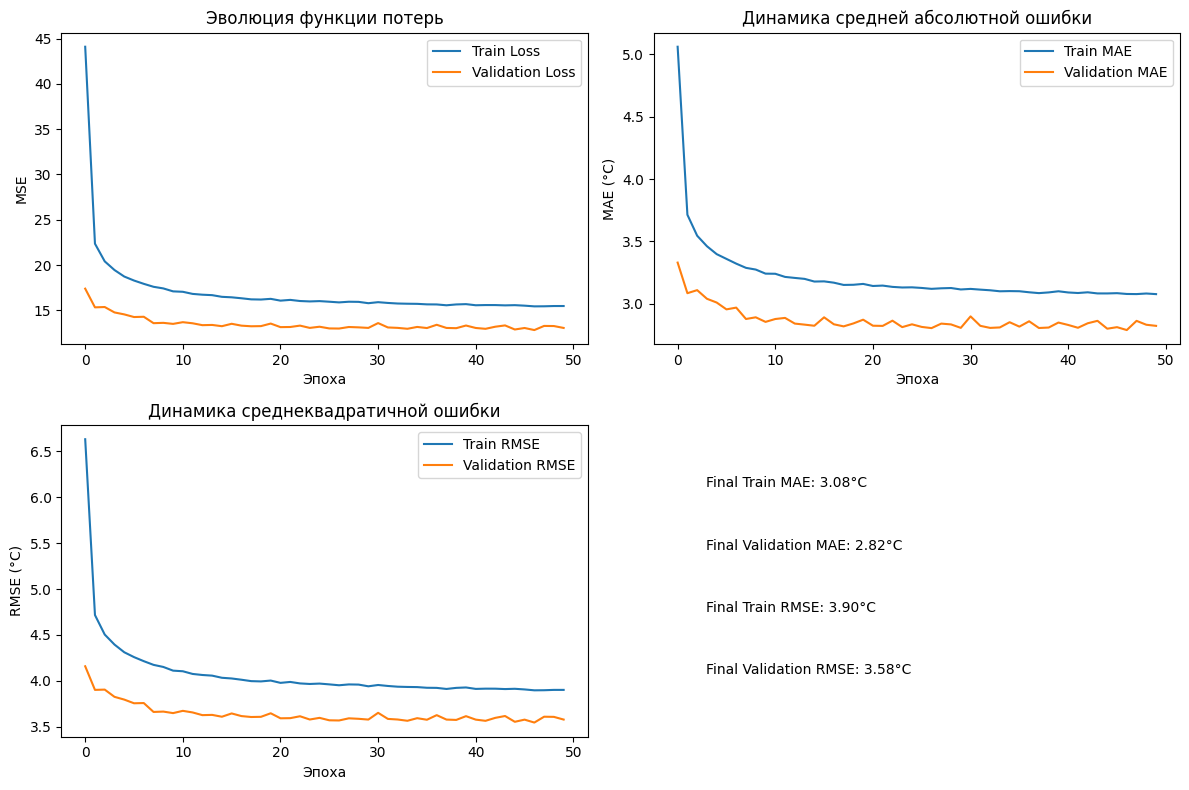


Результаты тестирования:
Средняя абсолютная ошибка (MAE): 2.82°C
Среднеквадратичная ошибка (RMSE): 3.58°C


In [6]:
# 1. Импорт библиотек
!pip install tensorflow
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import Sequential, regularizers
from tensorflow.keras.layers import Dense, Dropout, LeakyReLU

# 2. Загрузка данных
df = pd.read_csv('/content/weatherHistory.csv')

# 3. Предобработка данных
# 3.1. Преобразование времени
df['Formatted Date'] = pd.to_datetime(df['Formatted Date'], utc=True)
df['Hour'] = df['Formatted Date'].dt.hour
df['Day_of_Year'] = df['Formatted Date'].dt.dayofyear

# 3.2. Удаление ненужных столбцов
columns_to_drop = ['Formatted Date', 'Daily Summary', 'Summary']
df = df.drop(columns=columns_to_drop, errors='ignore')

# 3.3. Обработка пропусков (исправленный метод)
df = df.ffill()  # Вместо fillna(method='ffill')

# 4. Выбор признаков и целевой переменной
features = [
    'Humidity',
    'Wind Speed (km/h)',
    'Pressure (millibars)',
    'Hour',
    'Day_of_Year'
]
target = 'Temperature (C)'

X = df[features]
y = df[target]

# 5. Разделение данных
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 6. Обработка категориальных признаков
cat_cols = []
if cat_cols:
    ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    ohe.fit(X_train[cat_cols])
    X_train_cat = ohe.transform(X_train[cat_cols])
    X_test_cat = ohe.transform(X_test[cat_cols])
else:
    X_train_cat = np.zeros((X_train.shape[0], 0))
    X_test_cat = np.zeros((X_test.shape[0], 0))

# 7. Стандартизация числовых признаков
num_cols = [col for col in features if col not in cat_cols]
scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train[num_cols])
X_test_num = scaler.transform(X_test[num_cols])

# 8. Объединение признаков
X_train_processed = np.hstack([X_train_num, X_train_cat])
X_test_processed = np.hstack([X_test_num, X_test_cat])

# 9. Создание нейронной сети с регуляризацией
model = Sequential([
    Dense(64,
          kernel_regularizer=regularizers.l2(0.001),
          input_shape=(X_train_processed.shape[1],)),
    LeakyReLU(negative_slope=0.01),  # Исправленный параметр
    Dropout(0.3),

    Dense(32,
          kernel_regularizer=regularizers.l2(0.001)),
    LeakyReLU(negative_slope=0.01),
    Dropout(0.2),

    Dense(16,
          kernel_regularizer=regularizers.l2(0.001)),
    LeakyReLU(negative_slope=0.01),
    Dropout(0.1),

    Dense(1)
])

# 10. Компиляция модели (обязательный этап перед обучением)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae', tf.keras.metrics.RootMeanSquaredError()]
)

# 11. Обучение модели
history = model.fit(
    X_train_processed,
    y_train,
    validation_data=(X_test_processed, y_test),
    epochs=50,
    batch_size=64,
    verbose=1
)

# 12. Визуализация процесса обучения
import matplotlib.pyplot as plt

def plot_training_history(history):
    plt.figure(figsize=(12, 8))

    # График потерь (MSE)
    plt.subplot(2, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Эволюция функции потерь')
    plt.ylabel('MSE')
    plt.xlabel('Эпоха')
    plt.legend()

    # График MAE
    plt.subplot(2, 2, 2)
    plt.plot(history.history['mae'], label='Train MAE')
    plt.plot(history.history['val_mae'], label='Validation MAE')
    plt.title('Динамика средней абсолютной ошибки')
    plt.ylabel('MAE (°C)')
    plt.xlabel('Эпоха')
    plt.legend()

    # График RMSE
    plt.subplot(2, 2, 3)
    plt.plot(history.history['root_mean_squared_error'], label='Train RMSE')
    plt.plot(history.history['val_root_mean_squared_error'], label='Validation RMSE')
    plt.title('Динамика среднеквадратичной ошибки')
    plt.ylabel('RMSE (°C)')
    plt.xlabel('Эпоха')
    plt.legend()

    # Общая статистика
    plt.subplot(2, 2, 4)
    plt.axis('off')
    plt.text(0.1, 0.8, f'Final Train MAE: {history.history["mae"][-1]:.2f}°C', fontsize=10)
    plt.text(0.1, 0.6, f'Final Validation MAE: {history.history["val_mae"][-1]:.2f}°C', fontsize=10)
    plt.text(0.1, 0.4, f'Final Train RMSE: {history.history["root_mean_squared_error"][-1]:.2f}°C', fontsize=10)
    plt.text(0.1, 0.2, f'Final Validation RMSE: {history.history["val_root_mean_squared_error"][-1]:.2f}°C', fontsize=10)

    plt.tight_layout()
    plt.show()

plot_training_history(history)

# 13. Оценка модели
test_loss, test_mae, test_rmse = model.evaluate(X_test_processed, y_test, verbose=0)
print(f'\nРезультаты тестирования:')
print(f'Средняя абсолютная ошибка (MAE): {test_mae:.2f}°C')
print(f'Среднеквадратичная ошибка (RMSE): {test_rmse:.2f}°C')

# **Сравнение 3 моделей по метрикам качества с визуализацией результата**

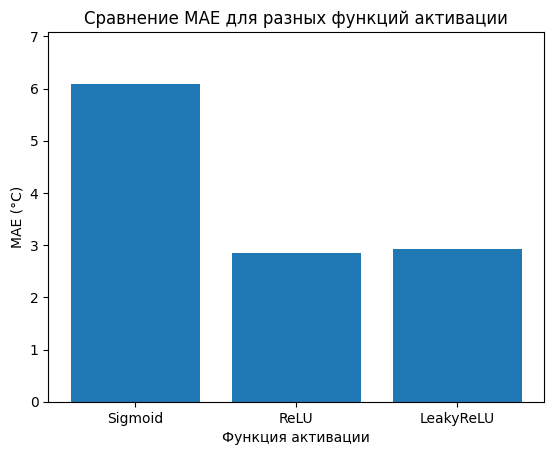

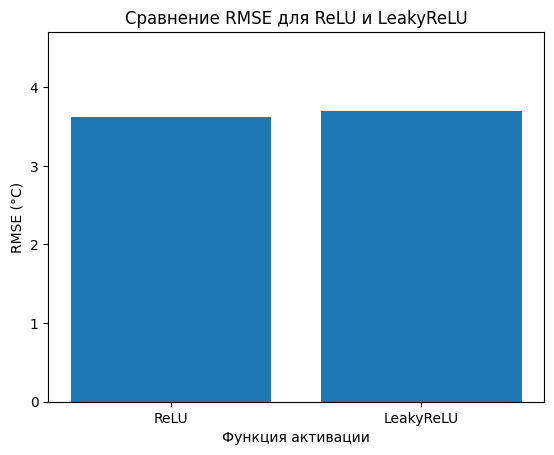

In [7]:
import matplotlib.pyplot as plt

# Data for visualization
models = ['Sigmoid', 'ReLU', 'LeakyReLU']
mae_values = [6.08, 2.84, 2.92]
rmse_models = ['ReLU', 'LeakyReLU']
rmse_values = [3.62, 3.70]

# Plot MAE comparison
plt.figure()
plt.bar(models, mae_values)
plt.title('Сравнение MAE для разных функций активации')
plt.xlabel('Функция активации')
plt.ylabel('MAE (°C)')
plt.ylim(0, max(mae_values) + 1)
plt.show()

# Plot RMSE comparison
plt.figure()
plt.bar(rmse_models, rmse_values)
plt.title('Сравнение RMSE для ReLU и LeakyReLU')
plt.xlabel('Функция активации')
plt.ylabel('RMSE (°C)')
plt.ylim(0, max(rmse_values) + 1)
plt.show()
